# CrimeCast: Analyzing the Impact of Temperature on Crime in Minneapolis

**Core Question:** Does temperature significantly influence daily crime rates in Minneapolis?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

pd.set_option('display.max_columns', None)

## 1. Data Loading & Overview
We load the merged crime and weather dataset and inspect its structure, data types, and missing values.

In [8]:
df=pd.read_csv('dataset.csv')

In [ ]:
df.head()

(207035, 19)
Unnamed: 0                                  int64
Offense_Category                              str
Precinct                                  float64
Ward                                      float64
Neighborhood                                  str
Time_To_Report                            float64
Date                               datetime64[us]
Maximum Temperature degrees (F)           float64
Minimum Temperature degrees (F)           float64
Precipitation (inches)                    float64
Snow (inches)                             float64
Snow Depth (inches)                       float64
Mean_Temperature_F                        float64
Month                                       int32
Mean_Temp                                 float64
Season                                        str
Is_Weekend                                  int64
Year                                        int32
DayOfWeek                                   int32
dtype: object
Unnamed: 0             

,Unnamed: 0,Precinct,Ward,Time_To_Report,Date,Maximum Temperature degrees (F),Minimum Temperature degrees (F),Precipitation (inches),Snow (inches),Snow Depth (inches),Mean_Temperature_F,Month,Mean_Temp,Is_Weekend,Year,DayOfWeek
count,207035.000000,207035.000000,207035.000000,207035.000000,207035,207035.000000,207035.000000,207035.000000,207035.000000,207035.000000,207035.000000,207035.000000,207035.000000,207035.000000,207035.000000,207035.000000
mean,103517.000000,3.216418,6.251885,116.273343,2021-01-28 09:23:31.326586,59.219905,41.723684,0.082046,0.128180,1.315439,50.471795,6.771092,50.471795,0.295008,2020.556693,3.047953
min,0.000000,1.000000,1.000000,0.000000,2019-01-02 00:00:00,-13.000000,-28.000000,0.000000,0.000000,0.000000,-20.500000,1.000000,-20.500000,0.000000,2019.000000,0.000000
25%,51758.500000,2.000000,4.000000,0.000000,2020-02-13 00:00:00,39.000000,26.000000,0.000000,0.000000,0.000000,32.500000,4.000000,32.500000,0.000000,2020.000000,1.000000
50%,103517.000000,3.000000,6.000000,1.933333,2021-01-30 00:00:00,64.000000,44.000000,0.000000,0.000000,0.000000,54.000000,7.000000,54.000000,0.000000,2021.000000,3.000000
75%,155275.500000,4.000000,9.000000,17.766667,2022-01-23 00:00:00,80.000000,61.000000,0.030000,0.000000,0.000000,70.500000,10.000000,70.500000,1.000000,2022.000000,5.000000
max,207034.000000,5.000000,13.000000,38647.783333,2022-12-31 00:00:00,101.000000,79.000000,2.470000,11.000000,21.000000,90.000000,12.000000,90.000000,1.000000,2022.000000,6.000000
std,59766.000828,1.295556,3.076300,922.040041,NaN,23.668724,21.990249,0.237221,0.729737,2.983831,22.618260,3.274770,22.618260,0.456047,1.107065,2.002201


In [ ]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
df.describe()

## 2. Exploratory Data Analysis

### 2.1 Crime Count vs Mean Temperature
Higher temperatures are associated with more daily crimes. The regression line shows a clear positive trend.

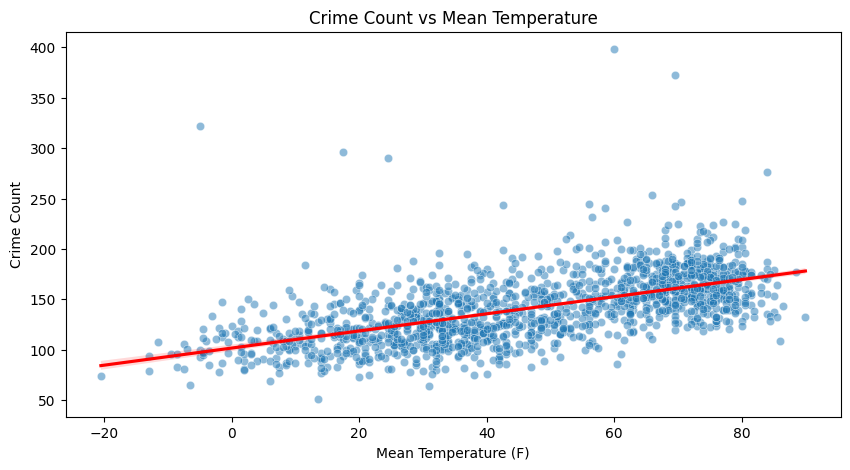

In [ ]:
# Add mean temperature column
df['Mean_Temperature_F'] = (df['Maximum Temperature degrees (F)'] + df['Minimum Temperature degrees (F)']) / 2

# Group by date
crime_temp = df.groupby('Date').agg(
    Crime_Count=('Offense_Category', 'count'),
    Mean_Temp=('Mean_Temperature_F', 'mean')
).reset_index()

plt.figure(figsize=(10, 5))
sns.scatterplot(data=crime_temp, x='Mean_Temp', y='Crime_Count', alpha=0.5)
sns.regplot(data=crime_temp, x='Mean_Temp', y='Crime_Count', scatter=False, color='red')
plt.title('Crime Count vs Mean Temperature')
plt.xlabel('Mean Temperature (F)')
plt.ylabel('Crime Count')
plt.show()

### 2.2 Top 10 Neighborhoods by Crime Count
Some neighborhoods consistently show higher crime volumes regardless of season.

/var/folders/2j/g1_b6vws5tggvbmgpcszcsch0000gn/T/ipykernel_4973/2175731917.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neighborhoods.values, y=top_neighborhoods.index, palette='viridis')


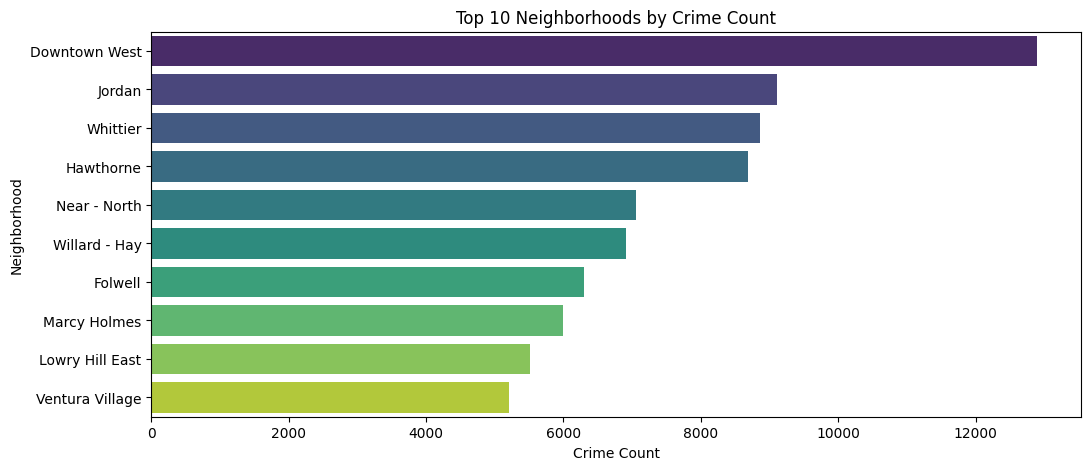

In [27]:
top_neighborhoods = df['Neighborhood'].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_neighborhoods.values, y=top_neighborhoods.index, palette='viridis')
plt.title('Top 10 Neighborhoods by Crime Count')
plt.xlabel('Crime Count')
plt.ylabel('Neighborhood')
plt.show()

### 2.3 Monthly Crime Trends
Crime follows a strong seasonal pattern, peaking in summer months and dropping in winter.

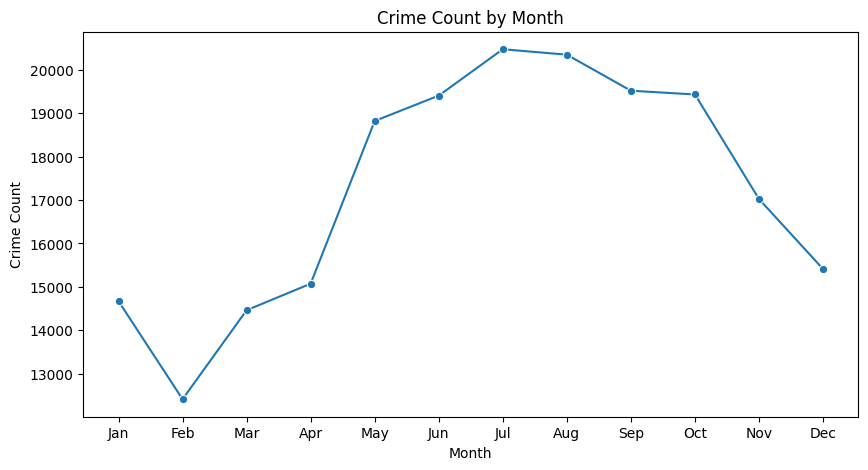

In [28]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

monthly_crime = df.groupby('Month').size().reset_index(name='Crime_Count')

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_crime, x='Month', y='Crime_Count', marker='o')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Crime Count by Month')
plt.xlabel('Month')
plt.ylabel('Crime Count')
plt.show()

### 2.4 Top 10 Offense Categories
Understanding which crime types are most common helps contextualize the overall crime count.

/var/folders/2j/g1_b6vws5tggvbmgpcszcsch0000gn/T/ipykernel_4973/596524363.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=offense_counts.values, y=offense_counts.index, palette='magma')


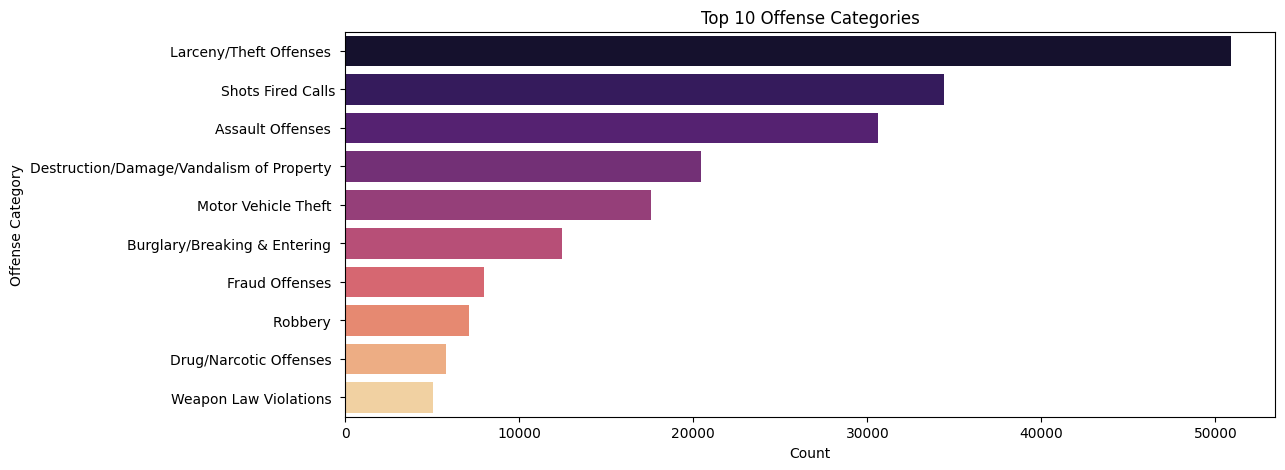

In [29]:
offense_counts = df['Offense_Category'].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=offense_counts.values, y=offense_counts.index, palette='magma')
plt.title('Top 10 Offense Categories')
plt.xlabel('Count')
plt.ylabel('Offense Category')
plt.show()

## 3. Feature Engineering
We create new features from the date and temperature columns to use in our predictive model, including season, day of week, weekend flag, and mean temperature.

In [30]:
df['Mean_Temp'] = (df['Maximum Temperature degrees (F)'] + df['Minimum Temperature degrees (F)']) / 2
df['Season'] = df['Date'].dt.month.map({12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall'})
df['Is_Weekend'] = pd.to_datetime(df['Date']).dt.dayofweek >= 5
df['Year'] = pd.to_datetime(df['Date']).dt.year

### 3.1 Correlation Heatmap
We examine how weather variables relate to each other and to reporting time. Strong correlations between features can affect model performance.

<Axes: >

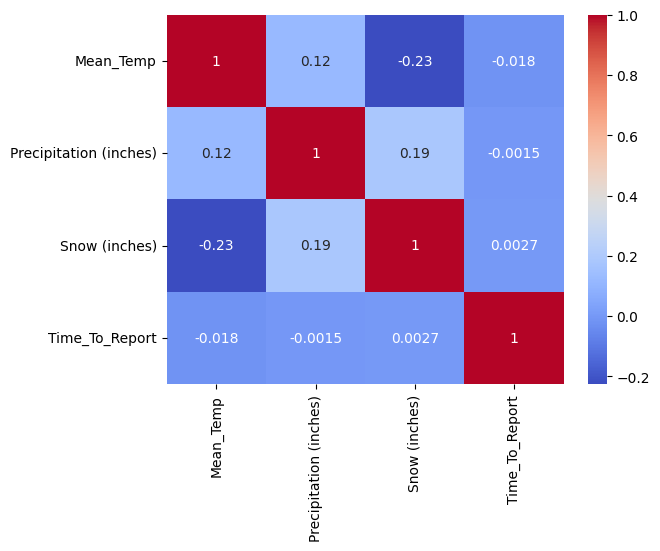

In [33]:
df['Time_To_Report'] = pd.to_timedelta(df['Time_To_Report']).dt.total_seconds() / 3600  # converts to hours

sns.heatmap(df[['Mean_Temp','Precipitation (inches)','Snow (inches)','Time_To_Report']].corr(), annot=True, cmap='coolwarm')

> **Observation:** Mean temperature shows virtually no correlation with Time to Report, confirming it is an independent predictor of crime volume rather than a reporting artifact.

In [ ]:
# Make sure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Feature engineering
df['Mean_Temp'] = (df['Maximum Temperature degrees (F)'] + df['Minimum Temperature degrees (F)']) / 2
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['Season'] = df['Month'].map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Spring',4:'Spring',5:'Spring',
    6:'Summer',7:'Summer',8:'Summer',
    9:'Fall',10:'Fall',11:'Fall'
})

        Date  Mean_Temp  Month  Year  DayOfWeek  Is_Weekend  Season
0 2019-01-09       11.0      1  2019          2           0  Winter
1 2019-01-09       11.0      1  2019          2           0  Winter
2 2019-01-09       11.0      1  2019          2           0  Winter
3 2019-01-09       11.0      1  2019          2           0  Winter
4 2019-01-09       11.0      1  2019          2           0  Winter


In [36]:
# Group by date to get daily crime count + weather
daily_df = df.groupby('Date').agg(
    Crime_Count=('Offense_Category', 'count'),
    Mean_Temp=('Mean_Temp', 'mean'),
    Precipitation=('Precipitation (inches)', 'mean'),
    Snow=('Snow (inches)', 'mean'),
    Month=('Month', 'first'),
    Year=('Year', 'first'),
    DayOfWeek=('DayOfWeek', 'first'),
    Is_Weekend=('Is_Weekend', 'first'),
    Season=('Season', 'first')
).reset_index()

print(daily_df.shape)
print(daily_df.head())

(1460, 10)
        Date  Crime_Count  Mean_Temp  Precipitation  Snow  Month  Year  \
0 2019-01-02           88       14.0            0.0   0.0      1  2019   
1 2019-01-03          114       30.5            0.0   0.0      1  2019   
2 2019-01-04          103       37.5            0.0   0.0      1  2019   
3 2019-01-05          106       37.0            0.0   0.0      1  2019   
4 2019-01-06          126       31.0            0.0   0.0      1  2019   

   DayOfWeek  Is_Weekend  Season  
0          2           0  Winter  
1          3           0  Winter  
2          4           0  Winter  
3          5           1  Winter  
4          6           1  Winter  


In [ ]:
# Quick sanity check on daily_df
print(f"Date range: {daily_df['Date'].min()} to {daily_df['Date'].max()}")
print(f"Avg daily crimes: {daily_df['Crime_Count'].mean():.1f}")
print(f"Max daily crimes: {daily_df['Crime_Count'].max()}")
print(f"Min daily crimes: {daily_df['Crime_Count'].min()}")

## 4. Predictive Modeling
We group the data into daily records and train two models to predict daily crime count from weather and calendar features.

**Features used:** Mean Temperature, Precipitation, Snowfall, Month, Day of Week, Is Weekend, Season  
**Target variable:** Daily Crime Count  
**Train/Test Split:** 80% / 20%

In [37]:
# Encode Season as numbers
season_map = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Fall': 3}
daily_df['Season_Num'] = daily_df['Season'].map(season_map)

# Define features and target
features = ['Mean_Temp', 'Precipitation', 'Snow', 'Month', 'DayOfWeek', 'Is_Weekend', 'Season_Num']
X = daily_df[features]
y = daily_df['Crime_Count']

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train both models
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate both
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

print("--- Linear Regression ---")
print(f"R² Score:  {r2_score(y_test, lr_preds):.3f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, lr_preds)):.2f}")

print("\n--- Random Forest ---")
print(f"R² Score:  {r2_score(y_test, rf_preds):.3f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, rf_preds)):.2f}")

--- Linear Regression ---
R² Score:  0.484
RMSE:      23.90

--- Random Forest ---
R² Score:  0.404
RMSE:      25.69


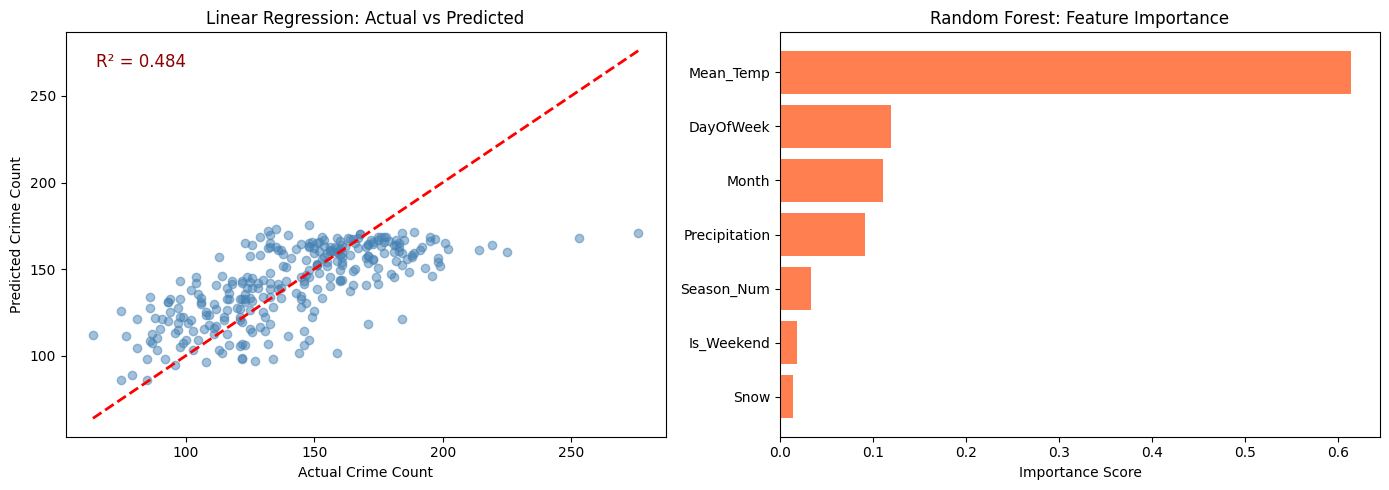

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Actual vs Predicted (Linear Regression) ---
axes[0].scatter(y_test, lr_preds, alpha=0.5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Actual Crime Count')
axes[0].set_ylabel('Predicted Crime Count')
axes[0].text(0.05, 0.95, f'R² = 0.484', transform=axes[0].transAxes,
             fontsize=12, verticalalignment='top', color='darkred')

# --- Plot 2: Feature Importance (Random Forest) ---
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(importance_df['Feature'], importance_df['Importance'], color='coral')
axes[1].set_title('Random Forest: Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Year-over-Year Trend Analysis
We examine how total crime counts changed across 2019–2022 and how seasonal patterns differ by year.

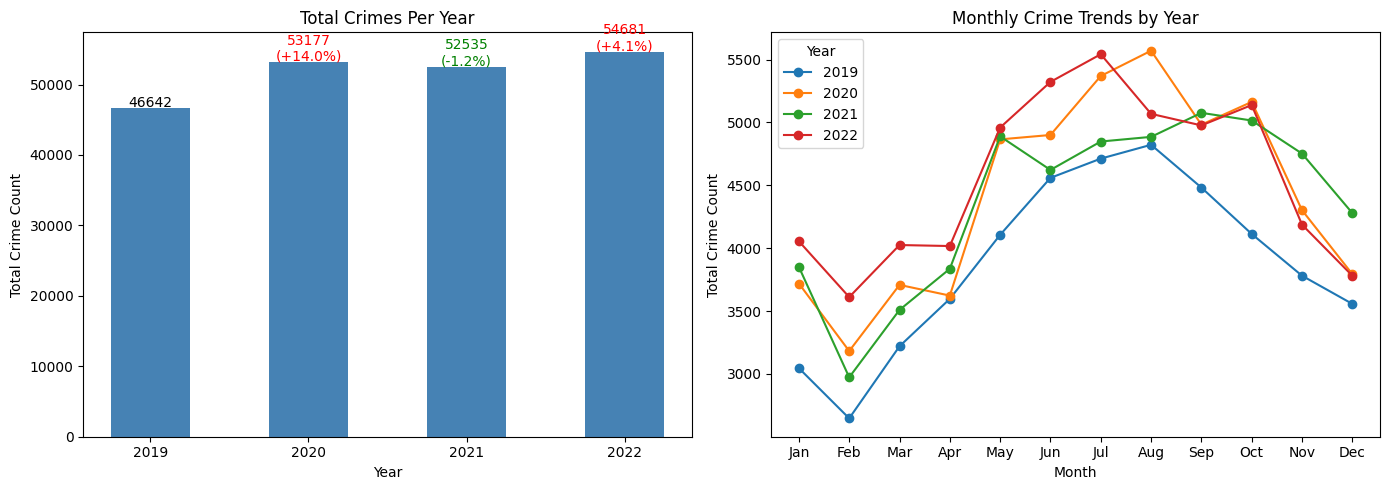

 Year  Crime_Count  YoY_Growth
 2019        46642         NaN
 2020        53177       14.01
 2021        52535       -1.21
 2022        54681        4.08


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Total crimes per year with YoY growth ---
yearly = daily_df.groupby('Year')['Crime_Count'].sum().reset_index()
yearly['Prev_Year'] = yearly['Crime_Count'].shift(1)
yearly['YoY_Growth'] = ((yearly['Crime_Count'] - yearly['Prev_Year']) / yearly['Prev_Year'] * 100).round(2)

bars = axes[0].bar(yearly['Year'], yearly['Crime_Count'], color='steelblue', width=0.5)
axes[0].set_title('Total Crimes Per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Crime Count')

# Add YoY % labels on bars
for i, row in yearly.iterrows():
    label = f"{int(row['Crime_Count'])}"
    if pd.notna(row['YoY_Growth']):
        color = 'green' if row['YoY_Growth'] < 0 else 'red'
        label += f"\n({row['YoY_Growth']:+.1f}%)"
    else:
        color = 'black'
    axes[0].text(row['Year'], row['Crime_Count'] + 200, label,
                ha='center', fontsize=10, color=color)

# --- Plot 2: Monthly crime trend by year ---
monthly_year = daily_df.groupby(['Year', 'Month'])['Crime_Count'].sum().reset_index()

for year in monthly_year['Year'].unique():
    data = monthly_year[monthly_year['Year'] == year]
    axes[1].plot(data['Month'], data['Crime_Count'], marker='o', label=str(year))

axes[1].set_title('Monthly Crime Trends by Year')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Crime Count')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1].legend(title='Year')

axes[0].set_xticks([2019, 2020, 2021, 2022])
axes[0].set_xticklabels(['2019', '2020', '2021', '2022'])

plt.tight_layout()
plt.savefig('yearly_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the YoY table
print(yearly[['Year','Crime_Count','YoY_Growth']].to_string(index=False))

### What the data tells us:

| Finding | Detail |
|---|---|
| Temperature is the #1 predictor | Feature importance score of 0.61 — far above all other variables |
| Model explains ~48% of variance | Linear Regression R² = 0.484, RMSE = 23.90 |
| Crime peaks in summer | July–August consistently show the highest crime across all 4 years |
| 2020 saw the largest spike | +14% YoY increase, likely driven by external social factors |
| Snowfall has minimal effect | Snow importance score near 0 — weather type matters less than temperature |

### What this means:
Temperature is a statistically significant and practically meaningful predictor of daily crime in Minneapolis. City planners and law enforcement could use temperature forecasts to anticipate higher-crime periods and allocate resources accordingly.

### Limitations:
- Dataset covers only 2019–2022 — a longer timeframe would strengthen conclusions
- Daily weather averages don't capture conditions at the exact time of each crime
- Correlation does not imply causation — other seasonal factors (school schedules, daylight hours) may contribute